# Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Load Dataset

In [2]:
df = pd.read_csv('/content/supply_2.csv')

# Display first rows and info
display(df.head())
#df.info()

,Timestamp,Supplier_ID,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index,Risk_Level,Risk_Score
0,2025-01-01,1001,0.282856,0.299648,0.523310,0.870833,0.488055,3131,0.309935,7,115.494114,Low,0.728783
1,2025-01-02,1001,0.212056,0.291640,0.500194,0.845376,0.452305,2916,0.303461,10,100.505035,Low,0.574813
2,2025-01-03,1001,0.201656,0.280311,0.545063,0.828287,0.390682,2808,0.309968,9,107.521521,Low,0.797338
3,2025-01-04,1001,0.234402,0.299422,0.521728,0.818679,0.404124,2619,0.317687,10,98.861438,Low,0.622711
4,2025-01-05,1001,0.256570,0.325887,0.505230,0.799296,0.367237,2631,0.355706,12,121.167108,Low,0.813507


# Data Preprocessing

In [3]:
# Converts the date column into datetime format
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort data and sets date as the index
df = df.sort_values(["Supplier_ID", "Timestamp"]).reset_index(drop=True)

In [4]:
feature_cols = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

# Encode Target

In [5]:
risk_order = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Risk_Encoded"] = df["Risk_Level"].map(risk_order)

#Split data
<───────────────────────────────────>

|──── 60% ────|──── 20% ────|──── 20% ────|
     Train          Validation       Test

In [6]:
times = np.sort(df["Timestamp"].unique())

train_end = times[int(len(times) * 0.60)]
val_end = times[int(len(times) * 0.80)]

train_df = df[df["Timestamp"] < train_end].copy()
val_df = df[(df["Timestamp"] >= train_end) & (df["Timestamp"] < val_end)].copy()
test_df = df[df["Timestamp"] >= val_end].copy()

# Scale the Data

In [7]:
#Each variable is scaled between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(train_df[feature_cols])
train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

# Convert Time Series into Sequences


In [8]:
# Transform the time-series data into sliding windows for LSTM input
# Uses the previous 7 days to predict the following day's risk level
# Horizon = 1 day

WINDOW = 7

def create_sequences(data, labels, supplier_ids, window):
    X = []
    y = []

    for supplier in np.unique(supplier_ids):

        mask = supplier_ids == supplier

        supplier_data = data[mask]
        supplier_labels = labels[mask]

        for i in range(window, len(supplier_data)):
            X.append(supplier_data[i - window:i])
            y.append(supplier_labels[i])

    return np.array(X), np.array(y)


In [9]:
X_train, y_train = create_sequences(
    train_scaled,
    train_df["Risk_Encoded"].values,
    train_df["Supplier_ID"].values,
    WINDOW
)

X_val, y_val = create_sequences(
    val_scaled,
    val_df["Risk_Encoded"].values,
    val_df["Supplier_ID"].values,
    WINDOW
)

X_test, y_test = create_sequences(
    test_scaled,
    test_df["Risk_Encoded"].values,
    test_df["Supplier_ID"].values,
    WINDOW
)

# Built the LSTM Model

In [10]:
#compute_class_weight from sklearn
classes = np.unique(y_train)

class_weights = dict(
    zip(classes, compute_class_weight("balanced", classes=classes, y=y_train))
)

In [11]:
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential(
    [
        LSTM(
            64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False
        ),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(3, activation="softmax"),
    ]
)

# COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


early_stopping = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123 (82.51 KB)

 Trainable params: 21,123 (82.51 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [12]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))


# 1. Predictions
y_prob = model.predict(X_test)

# 2. Convert probabilities to class labels
y_pred = np.argmax(y_prob, axis=1)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5615 - loss: 0.8760 - val_accuracy: 0.6181 - val_loss: 0.8032 - learning_rate: 0.0010
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6484 - loss: 0.7430 - val_accuracy: 0.6386 - val_loss: 0.7655 - learning_rate: 0.0010
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6740 - loss: 0.7038 - val_accuracy: 0.6559 - val_loss: 0.7263 - learning_rate: 0.0010
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6866 - loss: 0.6814 - val_accuracy: 0.6608 - val_loss: 0.7140 - learning_rate: 0.0010
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6951 - loss: 0.6585 - val_accuracy: 0.6808 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6992 - loss: 0.6514 - val_accuracy: 0.6860 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7048 - loss: 0.6403

## CLASSIFICATION REPORT

In [33]:
class_names = ["Low", "Medium", "High"]

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)

print(classification_report(y_test, y_pred, target_names=class_names))


------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

         Low       0.79      0.78      0.79      1369
      Medium       0.63      0.61      0.62      1340
        High       0.75      0.78      0.76       941

    accuracy                           0.72      3650
   macro avg       0.72      0.73      0.72      3650
weighted avg       0.72      0.72      0.72      3650



## Calculate metrics

In [29]:
# Macro F1
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

# Macro AUC
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", macro_f1)
print("Macro AUC:", macro_auc)



Accuracy: 0.7205479452054795
Macro F1: 0.7239825831593758
Macro AUC: 0.8835535620336509


## Confusion Matrix


Confusion Matrix
[[1068  297    4]
 [ 269  824  247]
 [  14  189  738]]


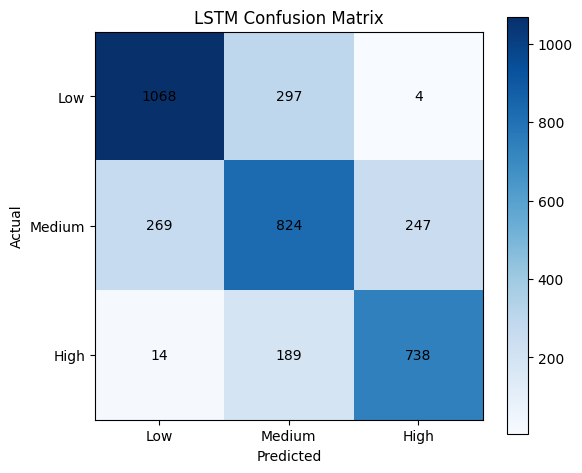

In [27]:
print("\n" + "=" * 60)
print("Confusion Matrix")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# CONFUSION MATRIX

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.imshow(cm, cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(class_names)), class_names)

plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

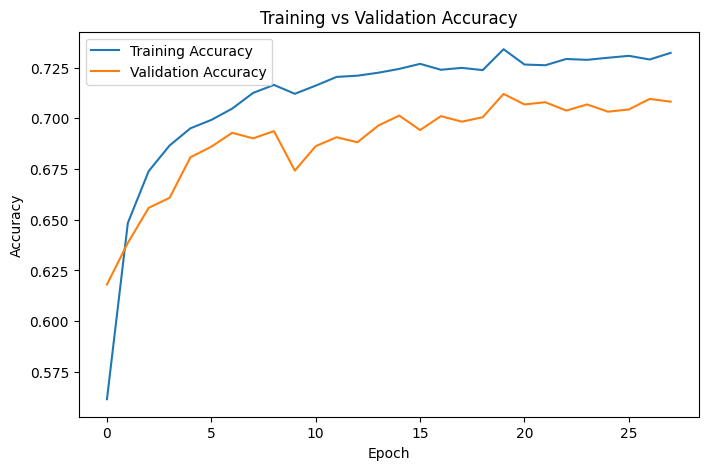

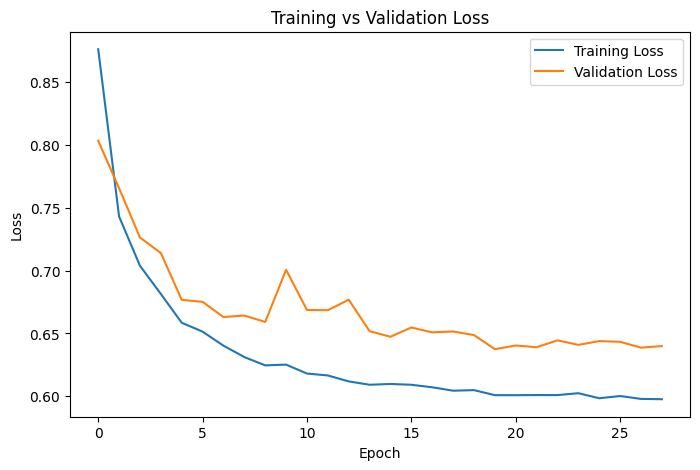

In [28]:
# TRAINING ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()
# TRAINING LOSS
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [30]:
#model.save("lstm_model.keras")

In [32]:
#import joblib
#joblib.dump(scaler, "scaler.pkl")